# 🛒 E-commerce Sales Analysis using Python

This project analyzes e-commerce sales data to understand sales, profit, products, categories, customers, payment methods and order status.


## Objectives
- Analyze total sales and profit
- Find best-performing categories and products
- Analyze monthly sales trends
- Study payment methods and order status
- Identify top states by revenue
- Create useful visualizations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/ecommerce_sales.csv')
df.head()


,Order_ID,Order_Date,Category,Product,State,Quantity,Unit_Price,Discount_Percent,Revenue,Cost,Profit,Customer_Rating,Payment_Method,Order_Status
0,ORD10001,2025-01-01,Electronics,Smartwatch,Tamil Nadu,4,43936,15,149382.4,136006.47,13375.93,2.5,Net Banking,Delivered
1,ORD10002,2025-01-01,Beauty,Moisturizer,Telangana,3,3337,10,9009.9,7111.87,1898.03,3.6,UPI,Delivered
2,ORD10003,2025-01-01,Beauty,Moisturizer,Karnataka,4,20026,20,64083.2,49352.94,14730.26,4.0,Cash on Delivery,Delivered
3,ORD10004,2025-01-02,Home & Kitchen,Bedsheet,Delhi,4,23048,15,78363.2,69266.82,9096.38,3.7,Debit Card,Delivered
4,ORD10005,2025-01-02,Home & Kitchen,Mixer,West Bengal,3,39944,0,119832.0,68640.95,51191.05,2.8,Cash on Delivery,Delivered


In [2]:
df.shape
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   str    
 1   Order_Date        1000 non-null   str    
 2   Category          1000 non-null   str    
 3   Product           1000 non-null   str    
 4   State             1000 non-null   str    
 5   Quantity          1000 non-null   int64  
 6   Unit_Price        1000 non-null   int64  
 7   Discount_Percent  1000 non-null   int64  
 8   Revenue           1000 non-null   float64
 9   Cost              1000 non-null   float64
 10  Profit            1000 non-null   float64
 11  Customer_Rating   1000 non-null   float64
 12  Payment_Method    1000 non-null   str    
 13  Order_Status      1000 non-null   str    
dtypes: float64(4), int64(3), str(7)
memory usage: 171.4 KB


Order_ID            0
Order_Date          0
Category            0
Product             0
State               0
Quantity            0
Unit_Price          0
Discount_Percent    0
Revenue             0
Cost                0
Profit              0
Customer_Rating     0
Payment_Method      0
Order_Status        0
dtype: int64

In [3]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print('Total Revenue:', round(df['Revenue'].sum(),2))
print('Total Profit:', round(df['Profit'].sum(),2))
print('Total Orders:', df['Order_ID'].nunique())
print('Total Quantity:', df['Quantity'].sum())


Total Revenue: 56341678.9
Total Profit: 13580293.06
Total Orders: 1000
Total Quantity: 2485


## 1. Category Analysis

Category
Home & Kitchen    13043638.90
Electronics       12447260.00
Sports            11090621.85
Beauty            10867755.15
Fashion            8892403.00
Name: Revenue, dtype: float64


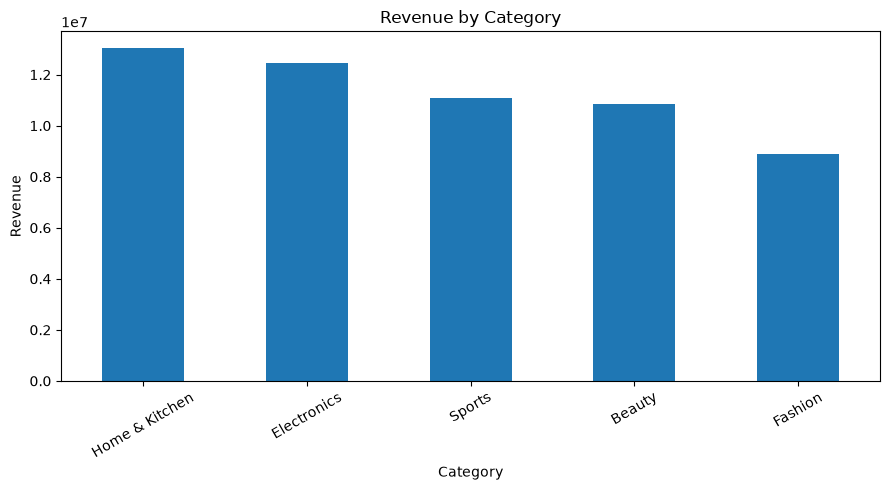

In [4]:
category_sales = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
print(category_sales)
category_sales.plot(kind='bar', figsize=(9,5), title='Revenue by Category')
plt.ylabel('Revenue'); plt.xlabel('Category'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 2. Monthly Sales Trend

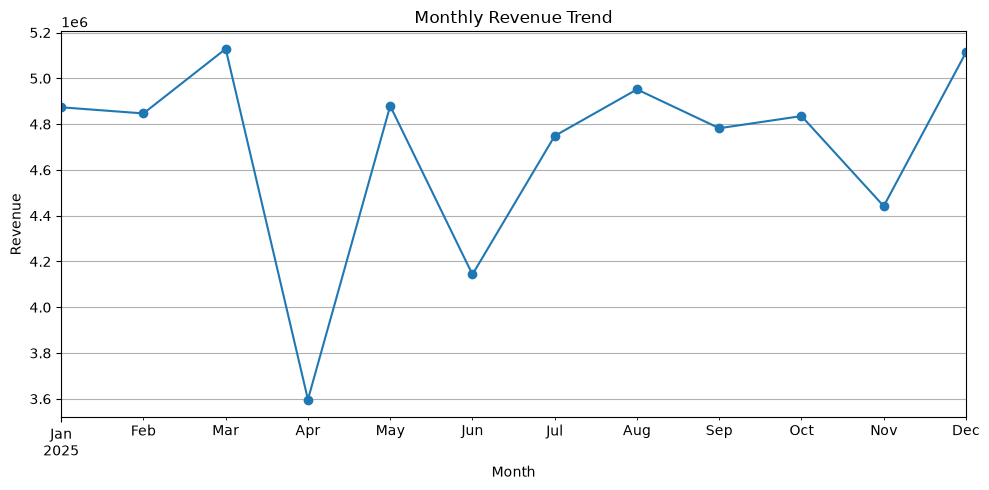

In [5]:
monthly_sales = df.set_index('Order_Date').resample('ME')['Revenue'].sum()
monthly_sales.plot(kind='line', marker='o', figsize=(10,5), title='Monthly Revenue Trend')
plt.ylabel('Revenue'); plt.xlabel('Month'); plt.grid(True); plt.tight_layout(); plt.show()


## 3. Top 10 Products

Product
Cookware Set     4162165.00
Smartwatch       4105425.75
Running Shoes    3350855.40
Mixer            3324715.85
Smartphone       3219103.65
Face Wash        3182828.85
Lamp             3038920.85
Cricket Bat      2974647.95
Perfume          2769781.65
Laptop           2757054.30
Name: Revenue, dtype: float64


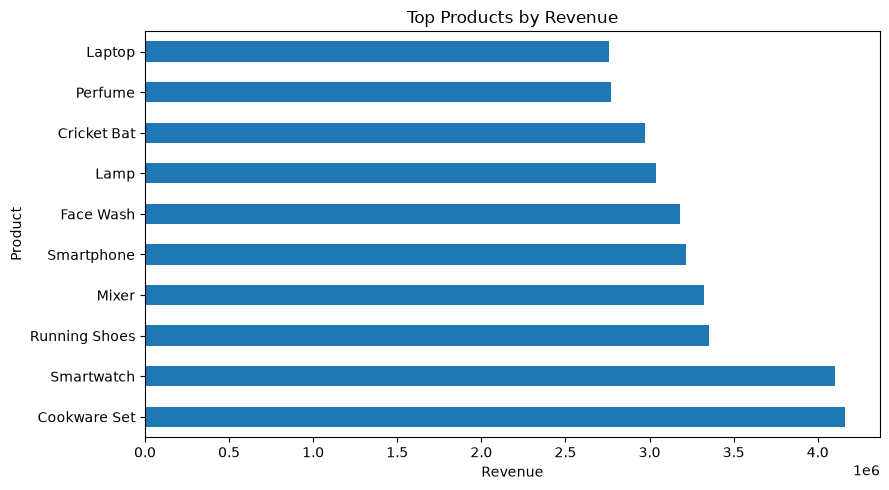

In [6]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)
print(top_products)
top_products.plot(kind='barh', figsize=(9,5), title='Top Products by Revenue')
plt.xlabel('Revenue'); plt.tight_layout(); plt.show()


## 4. State-wise Analysis

State
Gujarat        9104597.10
West Bengal    8808060.40
Telangana      8318663.40
Karnataka      8293376.95
Tamil Nadu     7555469.75
Delhi          7341438.30
Maharashtra    6920073.00
Name: Revenue, dtype: float64


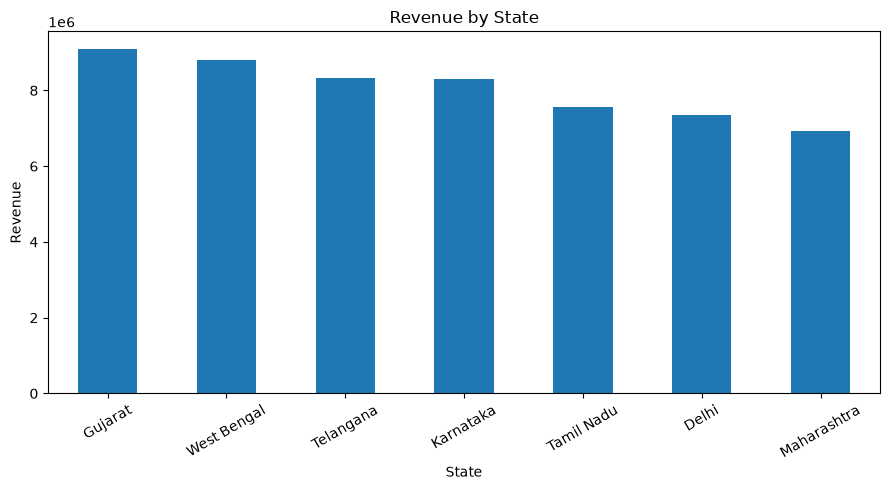

In [7]:
state_sales = df.groupby('State')['Revenue'].sum().sort_values(ascending=False)
print(state_sales)
state_sales.plot(kind='bar', figsize=(9,5), title='Revenue by State')
plt.ylabel('Revenue'); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 5. Payment Method Analysis

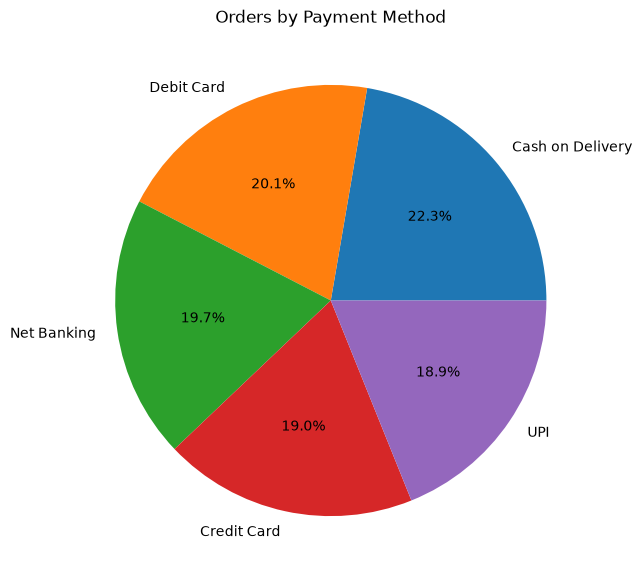

In [8]:
payment_counts = df['Payment_Method'].value_counts()
payment_counts.plot(kind='pie', autopct='%1.1f%%', figsize=(7,7), title='Orders by Payment Method')
plt.ylabel(''); plt.show()


## 6. Order Status Analysis

Order_Status
Delivered    861
Cancelled     76
Returned      63
Name: count, dtype: int64


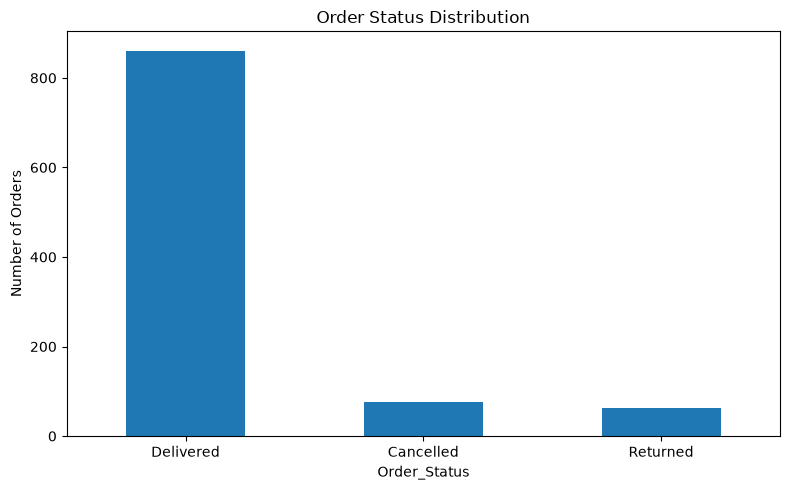

In [9]:
status_counts = df['Order_Status'].value_counts()
print(status_counts)
status_counts.plot(kind='bar', figsize=(8,5), title='Order Status Distribution')
plt.ylabel('Number of Orders'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()


## 7. Key Insights

In [10]:
best_category = category_sales.idxmax()
best_product = top_products.idxmax()
best_state = state_sales.idxmax()
print(f'Best Category: {best_category}')
print(f'Top Product: {best_product}')
print(f'Top State: {best_state}')
print(f'Total Revenue: {df.Revenue.sum():,.2f}')
print(f'Total Profit: {df.Profit.sum():,.2f}')


Best Category: Home & Kitchen
Top Product: Cookware Set
Top State: Gujarat
Total Revenue: 56,341,678.90
Total Profit: 13,580,293.06


## Conclusion
The analysis provides a clear view of e-commerce performance. It helps identify profitable categories, high-performing products, important markets, customer payment preferences and order-status patterns. These insights can support inventory planning, marketing decisions and sales strategy.